In [35]:
from scipy.signal import spectrogram
from scipy.io import wavfile
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib as plt

In [36]:
import glob
from scipy.io import wavfile

# folder_path = "path/to/your/folder/*.wav"
# folder_path=r"C:\Users\yusle\Desktop\Fau Work 2023-2025\Fall 2025\Main Project\Test_UUV\*.wav"
folder_path=r"C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\*.wav"

for file_path in glob.glob(folder_path):
    # fs, data = wavfile.read(file_path)
    fs,x=wavfile.read(file_path)
    print("File:", file_path)
    print("Sample rate:", fs)
    print("Shape:", x.shape)
    #Time Domain Data (x X time)
    # plt.plot(x)
    # plt.xlabel('Time')
    # plt.ylabel('Amp')

File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\20220624110853_S_No7_F_W_0_label__0__5.wav
Sample rate: 52734
Shape: (158202,)
File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\20220624110853_S_No7_F_W_0_label__0__6.wav
Sample rate: 52734
Shape: (158202,)
File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\20220624110853_S_No7_F_W_0_label__0__7.wav
Sample rate: 52734
Shape: (158202,)
File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\20220624110853_S_No7_F_W_0_label__0__8.wav
Sample rate: 52734
Shape: (158202,)
File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\20220624110853_S_No7_F_W_0_label__0__9.wav
Sample rate: 52734
Shape: (158202,)
File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\clip_00000.wav
Sample rate: 16000
Shape: (48743,)
File: C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\clip_00011.wav
Sample rate: 16000
Shape: (14138,)
File: C:\Users\yusle\Desktop\Git Repositori

In [37]:
#Create Folder for storing images
import os
#creates folder for spectrogram images 
os.makedirs("TestUUV_IMG", exist_ok=True)

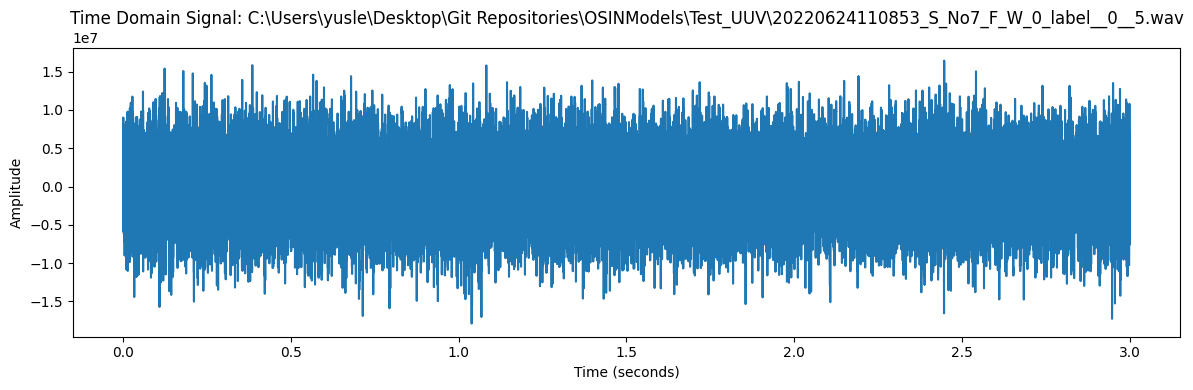

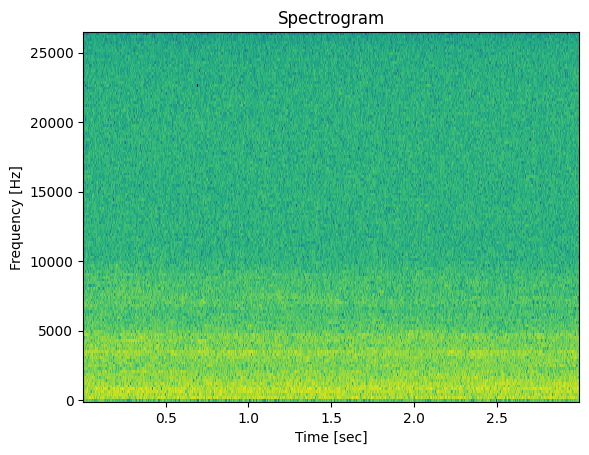

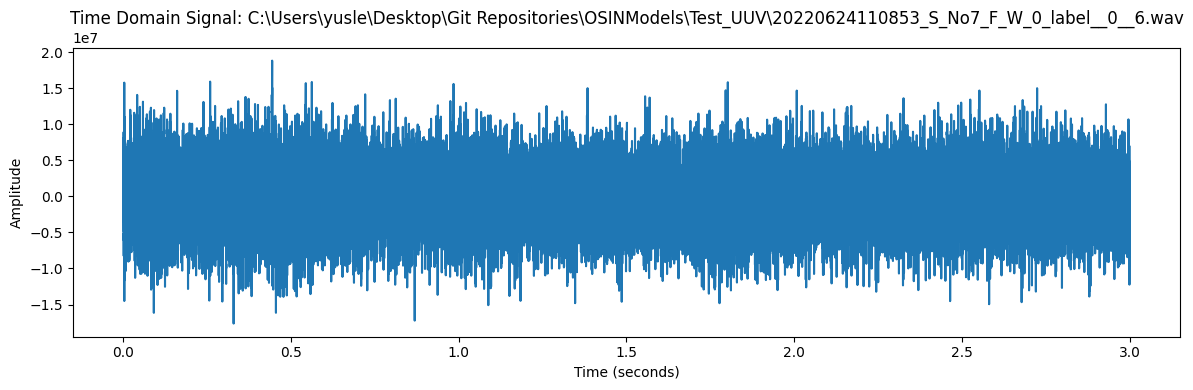

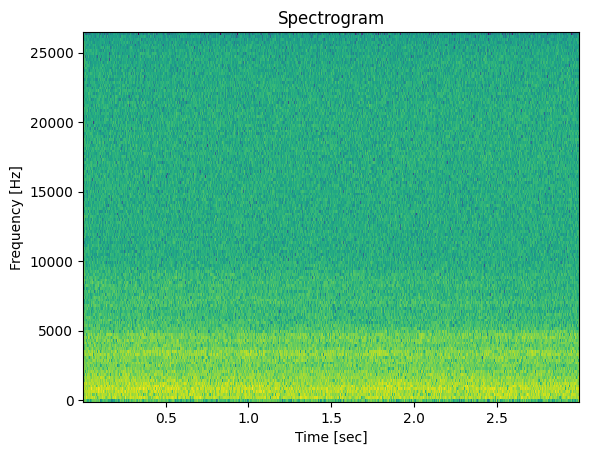

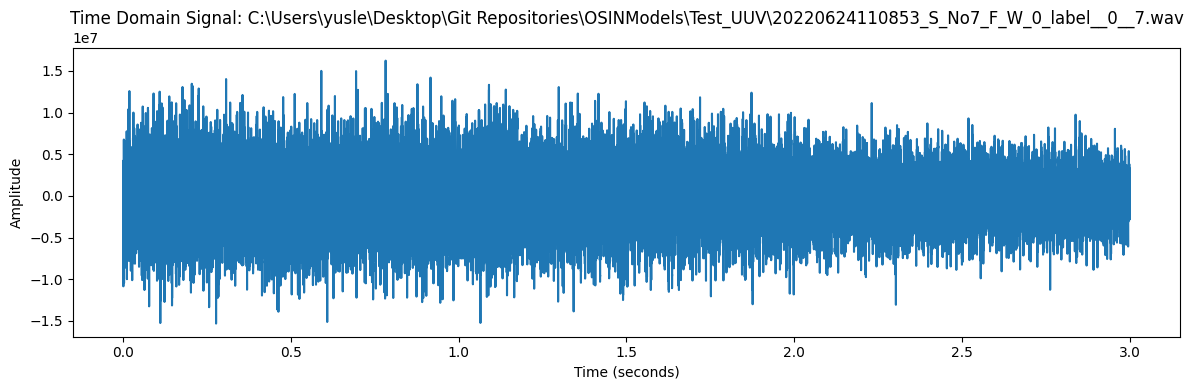

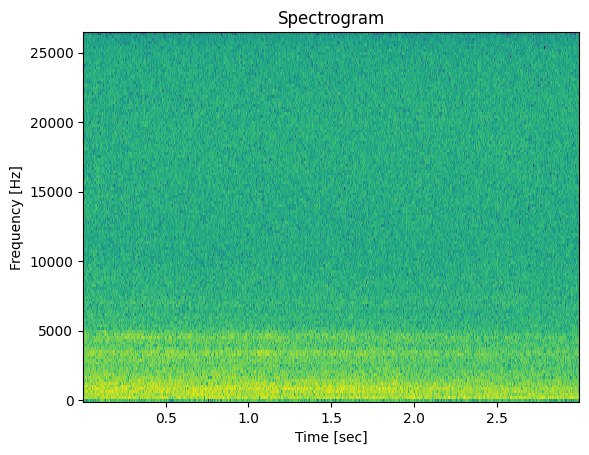

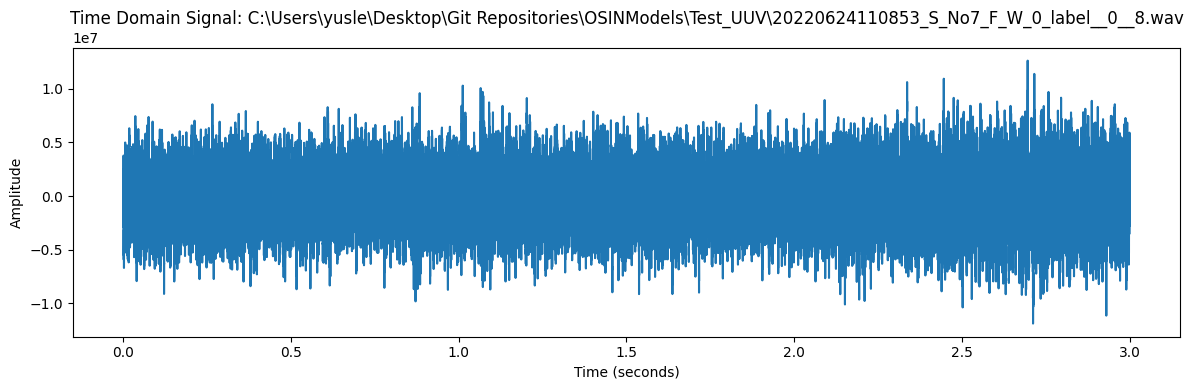

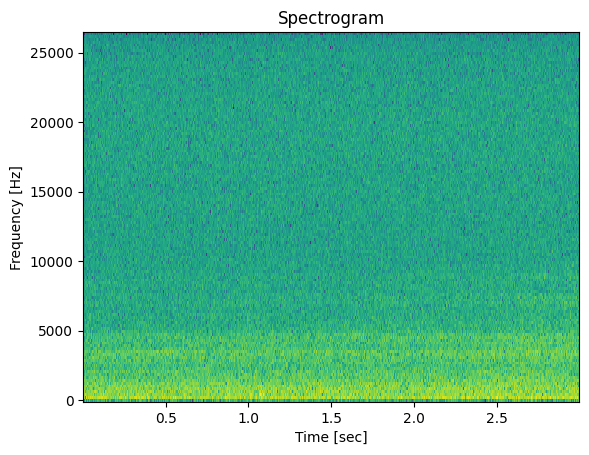

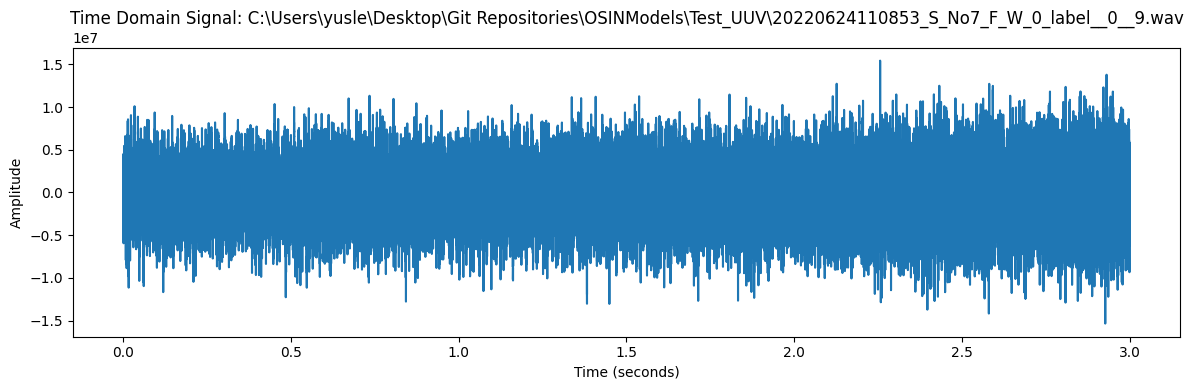

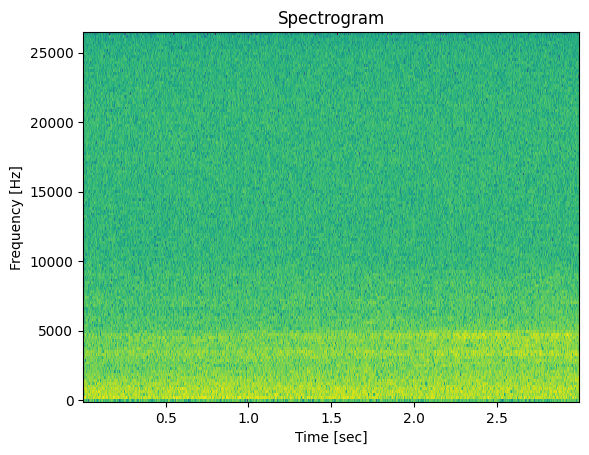

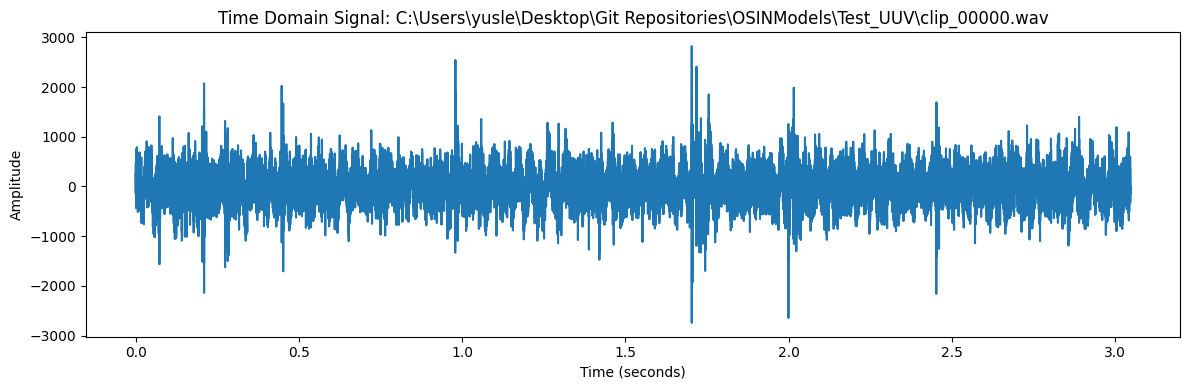

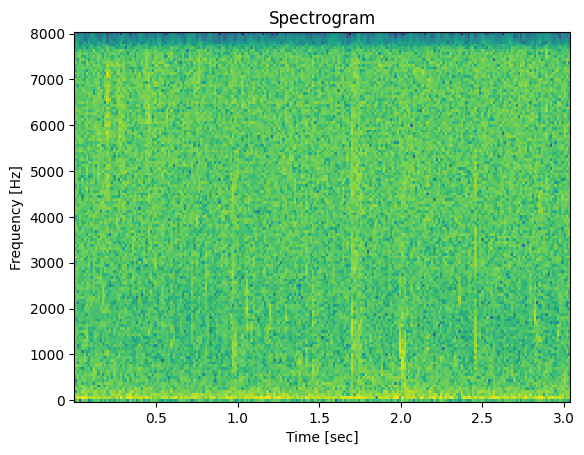

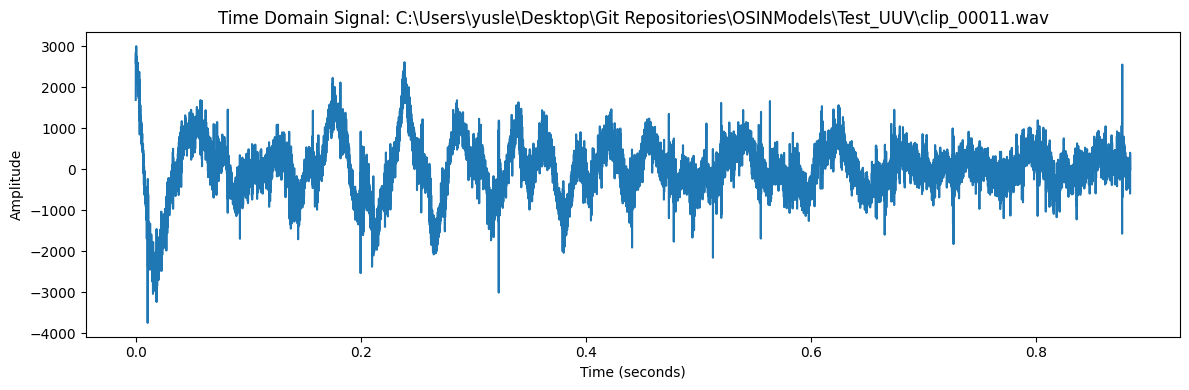

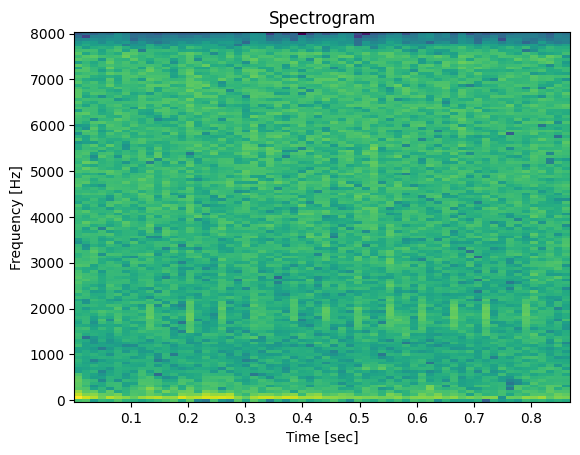

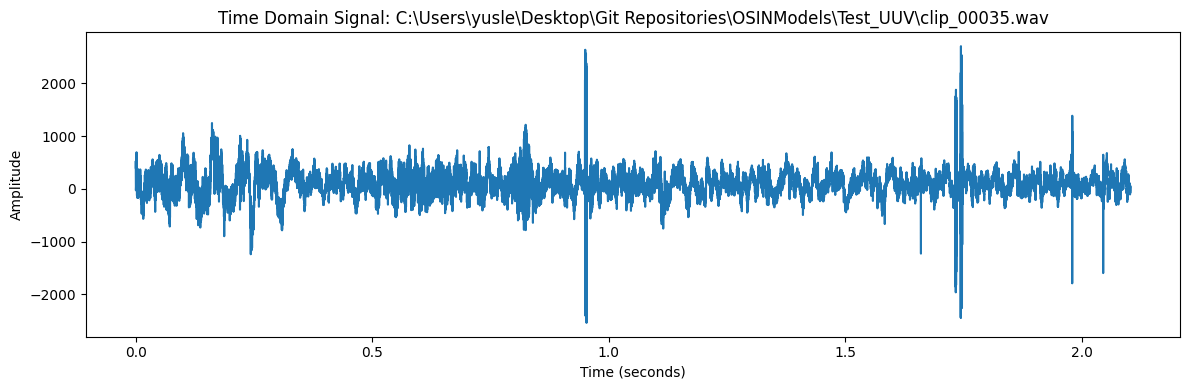

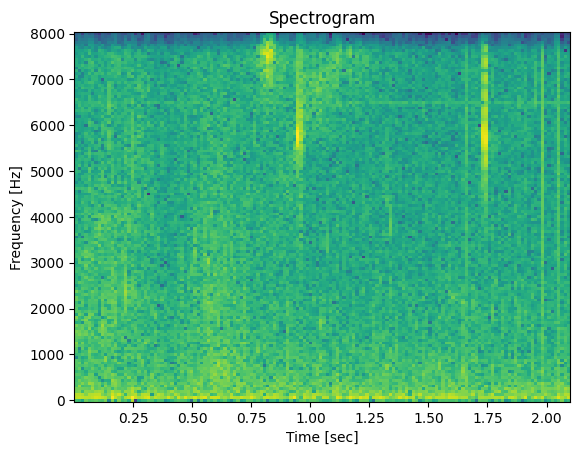

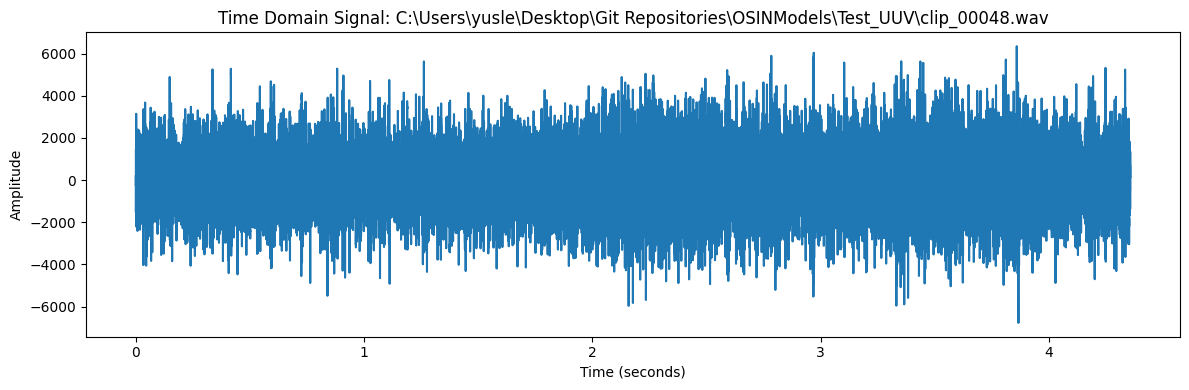

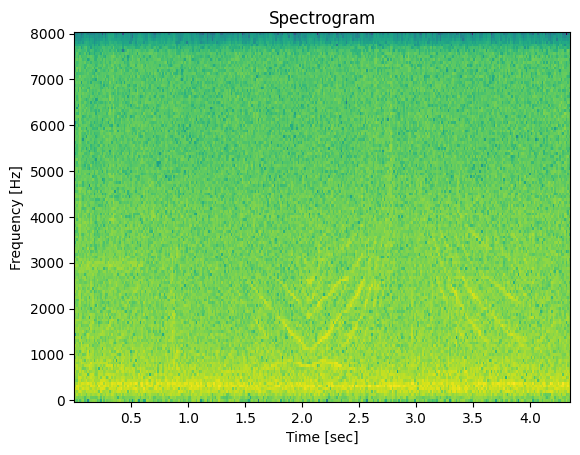

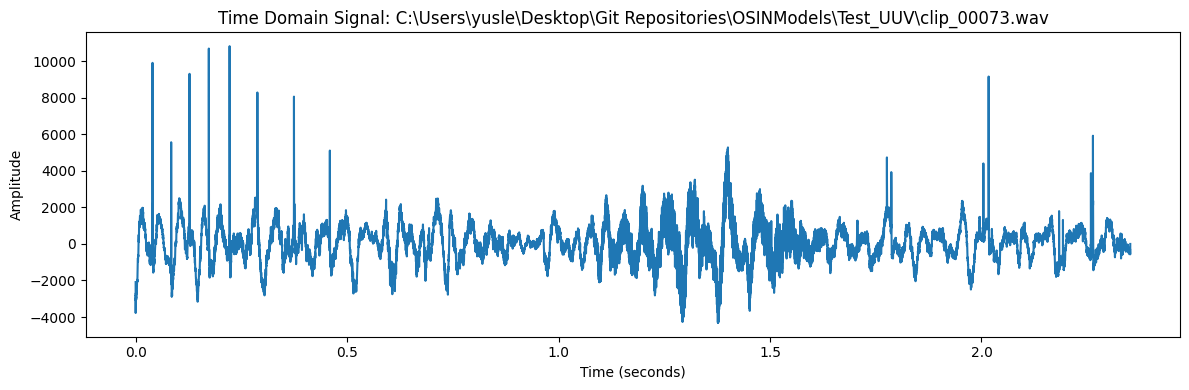

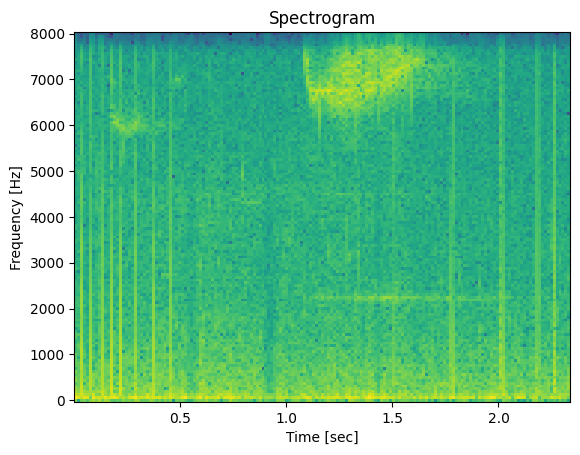

In [38]:
#Library Imports 
import glob
import matplotlib.pyplot as plt
from scipy.io import wavfile
import numpy as np

#folder path for sound files
folder_path=r"C:\Users\yusle\Desktop\Git Repositories\OSINModels\Test_UUV\*.wav"

#counter for file saving 
i=1

#loop for accessing file paths in specified folder path 
for file_path in glob.glob(folder_path):
    
    # Read WAV file
    fs, x = wavfile.read(file_path)

    # If stereo → convert to mono
    if len(x.shape) > 1:
        x = x.mean(axis=1)

    # Create time axis
    t = np.arange(len(x)) / fs

    # Plot time domain
    plt.figure(figsize=(12, 4))
    plt.plot(t, x)
    plt.title(f"Time Domain Signal: {file_path}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    #NFFT  is the fourier transform, that handles data not evenly spaced in time 
    nfft=512
    y=np.abs(fft(x,nfft))
    y=y[:nfft//2]

    #
    f = np.arange(0, nfft /2) * fs / nfft
    #Frequency Domain (Mag X Freq)
    # plt.plot(f,y)
    # plt.title('Frequency Domain')
    # plt.xlabel('frequency')
    # plt.ylabel('Mag')

    f, t, Sxx = spectrogram(x, fs)
    #Plotting Raw Spectrogram 
    # plt.pcolormesh(t,f,10*np.log10(Sxx))
    # plt.ylabel('Frequency')
    # plt.xlabel('Time [sec]')
    # plt.title('Spectrogram')

    #Masking Spectrogram
    # freq_min=0
    # freq_max=10000
    # f_mask=(f>=freq_min)&(f<=freq_max)
    # Sxx=Sxx[f_mask,:] #masking / isolating the sound 
    # f = f[f_mask]  

    plt.pcolormesh(t,f,10*np.log10(Sxx))
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.title('Spectrogram')
    plt.savefig(f"TestUUV_IMG/spectrogram{i}.png")   # Save image
    i=i+1







